Intel(R) Extension for Scikit-learn* enabled (https://github.com/intel/scikit-learn-intelex)


Using device: cuda:1
Preparing MSW dataset (cv_pad=True)
Loaded cache with 7790 slices.
Finished MSW: 7790 slices.
Responders: 61 | Nonresponders: 5 | Unlabeled: 45
Preparing CHH dataset (cv_pad=True)
Generating consensus mean mask from 37 subjects...
Injecting 3 unlabeled subjects for pretraining...


Caching Volumes:   0%|          | 0/40 [00:00<?, ?it/s]

DEBUG: Showing orientation for Subject 13...


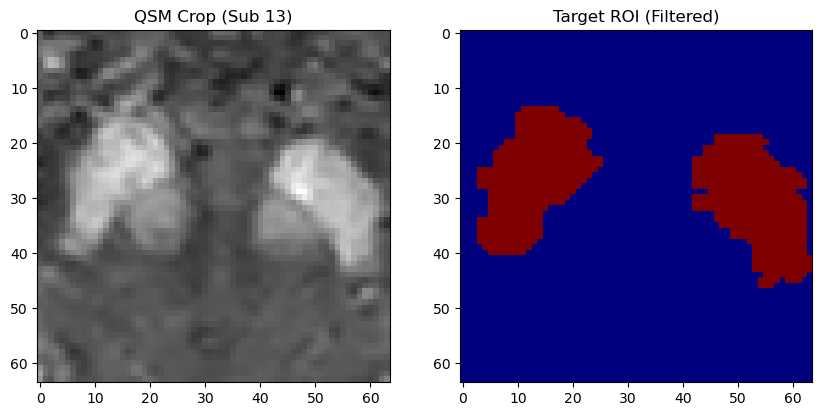

Caching Volumes: 100%|██████████| 40/40 [01:30<00:00,  2.27s/it]


Finished CHH: 2880 slices.
Responders: 34 | Nonresponders: 3 | Unlabeled: 3
Pretraining Minimal Spectral Attention + VAE...
Pretraining Minimal Spatial Attention + VAE...

Metric          | Ens Mani VAE    | Spectral ViT    | Spatial ViT    
-----------------------------------------------------------------
Accuracy        | 0.9238          | 0.9129          | 0.8848         
Sensitivity     | 0.9596          | 0.9420          | 0.9542         
Specificity     | 0.5185          | 0.5833          | 0.0972         
AUC             | 0.7919          | 0.7657          | 0.6644         
-----------------------------------------------------------------
Avg Threshold   | 0.1120          | 0.1280          | 0.1380         


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torchvision import transforms
import numpy as np
from tqdm import tqdm
from sklearnex import patch_sklearn
patch_sklearn()
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
# Ensure these match your networks.py or define MinimalSpectralAttention here
from networks import SupervisedManifoldVAE 
from sklearn.preprocessing import StandardScaler
from util import seed_everything, get_m, RandomMasking, prepare_qsm_dataset
from util import mask_crop as mask_crop_fn
from sklearn.metrics import f1_score, balanced_accuracy_score
from train import get_mixed_data
import copy

device = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

EXP_NAME = "msw_to_chh_kfold_leak_free"
N_PCA_COMPONENTS = 128
AUG_FACTOR = 5 
NEG_OVERSAMPLE_FACTOR = 10 
N_FOLDS = 5 # Standard 5-fold CV
seed_everything(0)

UNLABELED_CHH_PATH = "/media/mts_dbs/chh/nii/q" 

qsm_aug = transforms.Compose([
    transforms.RandomRotation(degrees=20),
    transforms.RandomAffine(degrees=0, translate=(0.08, 0.08), scale=(0.9, 1.1)),
    transforms.RandomApply([transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.1))], p=0.5),
    RandomMasking(p=0.4)
])

# ============================================================
# 2. DATA LOADING & PRE-PROCESSING
# ============================================================
dataset_msw = prepare_qsm_dataset('MSW', '/media/mts_dbs/dbs/all/nii/qsm_115/im', 
                                  '/media/mts_dbs/dbs/all/nii/seg_ps/',
                                  '/data/Ali/RadDBS-QSM/data/docs/dbs_03292024.csv', 
                                  'msw_cache_ax.pt', load_cache=True, mask_crop_fn=mask_crop_fn)

dataset_chh = prepare_qsm_dataset('CHH', '/media/mts_dbs/chh/nii/qsm/',
                                   '/media/mts_dbs/chh/nii/roi/',
                                    '/media/mts_dbs/chh/xlsx/chh_subjects_table1_20240729.csv',
                                    'chh_cache_ax_f.pt', load_cache=False, mask_crop_fn=mask_crop_fn, 
                                    unlabeled_nii_path=UNLABELED_CHH_PATH)

def get_mixed_data(dataset, factor=1, aug=None):
    l_imgs, l_clins, l_lbls, u_imgs, u_clins = [], [], [], [], []
    for idx in range(len(dataset)):
        img, clin, lbl, _ = dataset[idx]
        img_np = img.squeeze().numpy().flatten()
        if lbl != -1:
            reps = NEG_OVERSAMPLE_FACTOR if lbl == 0 else 1
            for _ in range(reps):
                l_imgs.append(img_np); l_clins.append(clin.numpy()); l_lbls.append(lbl)
                if aug and factor > 1:
                    for _ in range(factor-1):
                        a_img = aug(img.clone()).squeeze().numpy().flatten()
                        l_imgs.append(a_img); l_clins.append(clin.numpy()); l_lbls.append(lbl)
        else:
            u_imgs.append(img_np); u_clins.append(clin.numpy())
    return np.array(l_imgs), np.array(l_clins), np.array(l_lbls), np.array(u_imgs), np.array(u_clins)

X_tr_img, X_tr_clin, y_tr, X_msw_un_img, _ = get_mixed_data(dataset_msw, AUG_FACTOR, qsm_aug)
num_clin = X_tr_clin.shape[1]
_, _, _, X_chh_un_img, X_chh_un_clin = get_mixed_data(dataset_chh)

# Domain Alignment (Scalers/PCA)
all_imgs = np.vstack([X_tr_img, X_msw_un_img, X_chh_un_img])
img_scaler = StandardScaler().fit(all_imgs)
pca = PCA(n_components=N_PCA_COMPONENTS, random_state=0).fit(img_scaler.transform(all_imgs))

def process_features(imgs, clins):
    return np.hstack([pca.transform(img_scaler.transform(imgs)), clins])

X_tr_proc = process_features(X_tr_img, X_tr_clin)
X_chh_un_proc = process_features(X_chh_un_img, X_chh_un_clin)

feat_scaler = StandardScaler().fit(np.vstack([X_tr_proc, X_chh_un_proc]))
X_tr_final = feat_scaler.transform(X_tr_proc)
X_chh_un_final = feat_scaler.transform(X_chh_un_proc)

# Prep Test Set
X_te_img_list, X_te_clin_list, y_te_list = [], [], []
for i in range(len(dataset_chh)):
    img, clin, lbl, _ = dataset_chh[i]
    if lbl != -1:
        img_np = img.numpy().squeeze()
        if img_np.ndim == 3: img_np = img_np[:, :, img_np.shape[2]//2]
        X_te_img_list.append(img_np.flatten()); X_te_clin_list.append(clin.numpy()); y_te_list.append(lbl)

X_test_final = feat_scaler.transform(process_features(np.array(X_te_img_list), np.array(X_te_clin_list)))
y_test = np.array(y_te_list)

# ============================================================
# NEW: Minimal Spectral Attention (Residual + Hierarchy)
# ============================================================
class MinimalSpectralAttention(nn.Module):
    def __init__(self, n_components, embed_dim=16, n_heads=4):
        super().__init__()
        self.n_components = n_components
        self.input_projection = nn.Linear(1, embed_dim)
        self.mha = nn.MultiheadAttention(embed_dim, n_heads)
        self.output_projection = nn.Linear(embed_dim, 1)
        
        # Fixed variance-based weighting (The Hierarchy Prior)
        indices = torch.arange(n_components).float()
        # Decay factor: PCA 1 stays strong, PCA 128 is suppressed
        self.register_buffer('hierarchy_weight', torch.exp(-indices / 32).view(1, -1, 1))

    def forward(self, x):
        pca_raw = x[:, :self.n_components].unsqueeze(-1) 
        clin_feats = x[:, self.n_components:]
        
        # 1. Project with hierarchy weighting
        h = self.input_projection(pca_raw * self.hierarchy_weight) 
        
        # 2. Attention mechanism
        h = h.transpose(0, 1) 
        attn_out, _ = self.mha(h, h, h)
        h_out = attn_out.transpose(0, 1)
        
        # 3. Residual spectral context (Nonlinear refinement)
        spectral_context = self.output_projection(h_out)
        # We only add 10% of the attention's "opinion" to keep the VAE stable
        pca_out = (pca_raw + 0.1 * spectral_context).squeeze(-1) 
        
        return torch.cat([pca_out, clin_feats], dim=1)
    
class MinimalSpatialAttention(nn.Module):
    def __init__(self, img_dim=64, patch_size=8, embed_dim=16, n_heads=4):
        super().__init__()
        self.img_dim = img_dim
        self.n_img_feats = img_dim ** 2 # 4096
        self.patch_size = patch_size
        self.n_patches = (img_dim // patch_size) ** 2
        
        self.input_projection = nn.Linear(patch_size**2, embed_dim)
        
        # The "Fairness" counter-weight to the Spectral Hierarchy Prior
        self.pos_embedding = nn.Parameter(torch.randn(1, self.n_patches, embed_dim))
        
        self.mha = nn.MultiheadAttention(embed_dim, n_heads) 
        self.output_projection = nn.Linear(embed_dim, patch_size**2)

    def forward(self, x):
        # UNPACKING: Slices pixels (0:4096) and clinical (4096+)
        # This matches the "one tensor" input style of the Spectral class
        x_img_raw = x[:, :self.n_img_feats]
        x_clin = x[:, self.n_img_feats:]
        
        B = x_img_raw.shape[0]
        
        # 1. Tokenize Pixels into Patches
        x_img = x_img_raw.view(B, 1, self.img_dim, self.img_dim)
        # Unfold creates the grid of tokens
        patches = x_img.unfold(2, self.patch_size, self.patch_size)\
                       .unfold(3, self.patch_size, self.patch_size)\
                       .contiguous().view(B, self.n_patches, -1) 
        
        # 2. Project + Position (Spatial "Where" information)
        h = self.input_projection(patches) + self.pos_embedding
        
        # 3. Attention (Global context across the brain grid)
        h = h.transpose(0, 1)
        attn_out, _ = self.mha(h, h, h)
        h_out = attn_out.transpose(0, 1)
        
        # 4. Residual Refinement
        refined_patches = patches + 0.1 * self.output_projection(h_out)
        spatial_flat = refined_patches.view(B, -1)
        
        # 5. RE-PACKING: Concatenate clinical back for the VAE
        return torch.cat([spatial_flat, x_clin], dim=1)
    
# ============================================================
# 3. TRAINING REDUCED MODELS
# ============================================================
def calibrate(model, X_v, y_v):
    model.eval()
    with torch.no_grad():
        p = model(torch.tensor(X_v, dtype=torch.float32).to(device), mode='fine_tune').cpu().numpy()
    best_t, best_f1 = 0.5, 0
    for t in np.linspace(0.1, 0.9, 81):
        score = f1_score(y_v, (p >= t))
        if score > best_f1: best_f1, best_t = score, t
    return best_t

def calibrate_attn(model, attn, X_v, y_v):
    model.eval(); attn.eval()
    with torch.no_grad():
        x_t = torch.tensor(X_v, dtype=torch.float32).to(device)
        p = model(attn(x_t), mode='fine_tune').cpu().numpy()
    best_t, best_f1 = 0.5, 0
    for t in np.linspace(0.1, 0.9, 81):
        score = f1_score(y_v, (p >= t))
        if score > best_f1: best_f1, best_t = score, t
    return best_t

# Models
base_v = SupervisedManifoldVAE(X_tr_final.shape[1]).to(device)
base_va = SupervisedManifoldVAE(X_tr_final.shape[1]).to(device)
base_attn = MinimalSpectralAttention(N_PCA_COMPONENTS).to(device)
base_vs = SupervisedManifoldVAE(4096 + num_clin).to(device)
base_at_spatial = MinimalSpatialAttention(img_dim=64).to(device)

X_pre = torch.tensor(np.vstack([X_tr_final, X_chh_un_final]), dtype=torch.float32).to(device)
pre_loader = DataLoader(TensorDataset(X_pre), batch_size=128, shuffle=True)
mse = nn.MSELoss()

# Pretrain VAE only
opt_v = optim.Adam(base_v.parameters(), lr=1e-3)
for _ in range(30):
    for b in pre_loader:
        clean = b[0]
        opt_v.zero_grad()
        rec, mu1, logv1 = base_v(clean + torch.randn_like(clean)*0.05, mode='pretrain')
        loss = mse(rec, clean) + 0.01*(-0.5*torch.sum(1+logv1-mu1.pow(2)-logv1.exp())/clean.size(0))
        loss.backward(); opt_v.step()

# Joint pretraining for Minimal Spectral ViT
print("Pretraining Minimal Spectral Attention + VAE...")
opt_va = optim.Adam(list(base_va.parameters()) + list(base_attn.parameters()), lr=1e-3)
for _ in range(30):
    for b in pre_loader:
        clean = b[0]
        opt_va.zero_grad()
        v1 = base_attn(clean + torch.randn_like(clean)*0.05)
        rec, mu, logv = base_va(v1, mode='pretrain')
        loss = mse(rec, clean) + 0.01*(-0.5*torch.sum(1+logv-mu.pow(2)-logv.exp())/clean.size(0))
        loss.backward(); opt_va.step()

# 1. Create the unified Spatial vectors [Raw Pixels + Clinical]
X_tr_spatial_final = np.hstack([X_tr_img, X_tr_clin])
X_test_spatial_final = np.hstack([np.array(X_te_img_list), np.array(X_te_clin_list)])
X_chh_un_spatial = np.hstack([X_chh_un_img, X_chh_un_clin])

num_clin = X_tr_clin.shape[1]

# 2. Create the unified Spatial pre-loader
X_pre_spatial = torch.tensor(np.vstack([X_tr_spatial_final, X_chh_un_spatial]), dtype=torch.float32).to(device)
pre_loader_raw = DataLoader(TensorDataset(X_pre_spatial), batch_size=128, shuffle=True)

print("Pretraining Minimal Spatial Attention + VAE...")
opt_vs = optim.Adam(list(base_vs.parameters()) + list(base_at_spatial.parameters()), lr=1e-3)
for _ in range(30):
    for b in pre_loader_raw:
        clean = b[0]
        opt_vs.zero_grad()
        v_spatial = base_at_spatial(clean + torch.randn_like(clean)*0.05)
        rec, mu, logv = base_vs(v_spatial, mode='pretrain')
        loss = mse(rec, clean) + 0.01*(-0.5*torch.sum(1+logv-mu.pow(2)-logv.exp())/clean.size(0))
        loss.backward(); opt_vs.step()

# K-Fold Loop
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=0)
fold_preds_v, fold_preds_va, fold_preds_vs = [], [], []
fold_ths_v, fold_ths_va, fold_ths_vs = [], [], []

# New Calibration function using Balanced Accuracy
def calibrate_balanced(model, attn, X_v, y_v):
    model.eval()
    if attn: attn.eval()
    with torch.no_grad():
        x_t = torch.tensor(X_v, dtype=torch.float32).to(device)
        p = model(attn(x_t) if attn else x_t, mode='fine_tune').cpu().numpy()
    
    best_t, best_bal = 0.5, 0
    for t in np.linspace(0.01, 0.9, 100): # Wider sweep
        score = balanced_accuracy_score(y_v, (p >= t))
        if score > best_bal:
            best_bal, best_t = score, t
    return best_t

# --- Inside your K-Fold loop ---
# Lower the weight from 50 to 15-20
NEG_WEIGHT = 12

for fold, (train_idx, val_idx) in enumerate(skf.split(X_tr_final, y_tr)):
    # 1. Prepare Fold Data (Both PCA and Raw)
    X_f_train_pca, X_f_val_pca = X_tr_final[train_idx], X_tr_final[val_idx]
    X_f_train_raw, X_f_val_raw = X_tr_img[train_idx], X_tr_img[val_idx]
    X_f_train_spatial, X_f_val_spatial = np.hstack([X_tr_img[train_idx], X_tr_clin[train_idx]]), np.hstack([X_tr_img[val_idx], X_tr_clin[val_idx]])
    y_f_train, y_f_val = y_tr[train_idx], y_tr[val_idx]

    # 2. Initialize Models
    m_v, m_va, m_at = copy.deepcopy(base_v), copy.deepcopy(base_va), copy.deepcopy(base_attn)
    m_vs, m_ats = copy.deepcopy(base_vs), copy.deepcopy(base_at_spatial)

    # 3. Create Combined Dataloader
    # This yields (PCA_Features, Raw_Pixels, Labels)
    ft_loader = DataLoader(TensorDataset(
        torch.tensor(X_f_train_pca, dtype=torch.float32).to(device),
        torch.tensor(X_f_train_spatial, dtype=torch.float32).to(device),
        torch.tensor(y_f_train, dtype=torch.float32).to(device)
    ), batch_size=64, shuffle=True)

    # 4. Fine-Tune Optimizers
    opt_v = optim.Adam(m_v.parameters(), lr=1e-5, weight_decay=1e-2)
    opt_va = optim.Adam([{'params': m_va.parameters(), 'lr': 2e-5}, {'params': m_at.parameters(), 'lr': 8e-5}], weight_decay=5e-2)
    opt_vs = optim.Adam([{'params': m_vs.parameters(), 'lr': 2e-5}, {'params': m_ats.parameters(), 'lr': 8e-5}], weight_decay=5e-2)

    for _ in range(50):
        for b_pca, b_spatial, by in ft_loader:
            smoothed_labels = by * 0.95 + (1 - by) * 0.05
            weights = (by == 0).float() * NEG_WEIGHT + 1.0
            
            # FT VAE (PCA branch)
            opt_v.zero_grad()
            loss_v = nn.functional.binary_cross_entropy(m_v(b_pca, mode='fine_tune'), smoothed_labels, weight=weights)
            loss_v.backward(); opt_v.step()

            # FT Spectral ViT (PCA branch)
            opt_va.zero_grad()
            loss_va = nn.functional.binary_cross_entropy(m_va(m_at(b_pca), mode='fine_tune'), smoothed_labels, weight=weights)
            loss_va.backward(); opt_va.step()

            # FT Spatial ViT (Raw Pixel branch)
            opt_vs.zero_grad()
            loss_vs = nn.functional.binary_cross_entropy(m_vs(m_ats(b_spatial), mode='fine_tune'), smoothed_labels, weight=weights)
            loss_vs.backward(); opt_vs.step()

    # 5. Calibrate on Validation Fold
    fold_ths_v.append(calibrate(m_v, X_f_val_pca, y_f_val))
    fold_ths_va.append(calibrate_attn(m_va, m_at, X_f_val_pca, y_f_val))
    fold_ths_vs.append(calibrate_attn(m_vs, m_ats, X_f_val_spatial, y_f_val))
    
    # 6. Predict on Test Set
    with torch.no_grad():
        t_te_pca = torch.tensor(X_test_final, dtype=torch.float32).to(device)
        t_te_spatial = torch.tensor(X_test_spatial_final, dtype=torch.float32).to(device)
        
        fold_preds_v.append(m_v(t_te_pca, mode='fine_tune').cpu().numpy())
        fold_preds_va.append(m_va(m_at(t_te_pca), mode='fine_tune').cpu().numpy())
        fold_preds_vs.append(m_vs(m_ats(t_te_spatial), mode='fine_tune').cpu().numpy())
        
# ============================================================
# 4. FINAL EVALUATION & COMPARISON
# ============================================================

# 1. Aggregate predictions and thresholds across folds
pv  = np.mean(fold_preds_v, axis=0)
pva = np.mean(fold_preds_va, axis=0)
pvs = np.mean(fold_preds_vs, axis=0)

th_v  = np.mean(fold_ths_v)
th_va = np.mean(fold_ths_va)
th_vs = np.mean(fold_ths_vs)

# 2. Generate metrics for all three models
res = [
    get_m(y_test, (pv >= th_v), pv), 
    get_m(y_test, (pva >= th_va), pva),
    get_m(y_test, (pvs >= th_vs), pvs)
]

names = ['Ens Mani VAE', 'Spectral ViT', 'Spatial ViT']

# 3. Print Comparison Table
print(f"\n{'Metric':<15} | " + " | ".join([f"{n:<15}" for n in names]))
print("-" * 65)
for i, m_name in enumerate(['Accuracy', 'Sensitivity', 'Specificity', 'AUC']):
    row_values = " | ".join([f"{r[i]:<15.4f}" for r in res])
    print(f"{m_name:<15} | {row_values}")

# 4. Print Average Thresholds (Useful for debugging)
print("-" * 65)
print(f"{'Avg Threshold':<15} | {th_v:<15.4f} | {th_va:<15.4f} | {th_vs:<15.4f}")

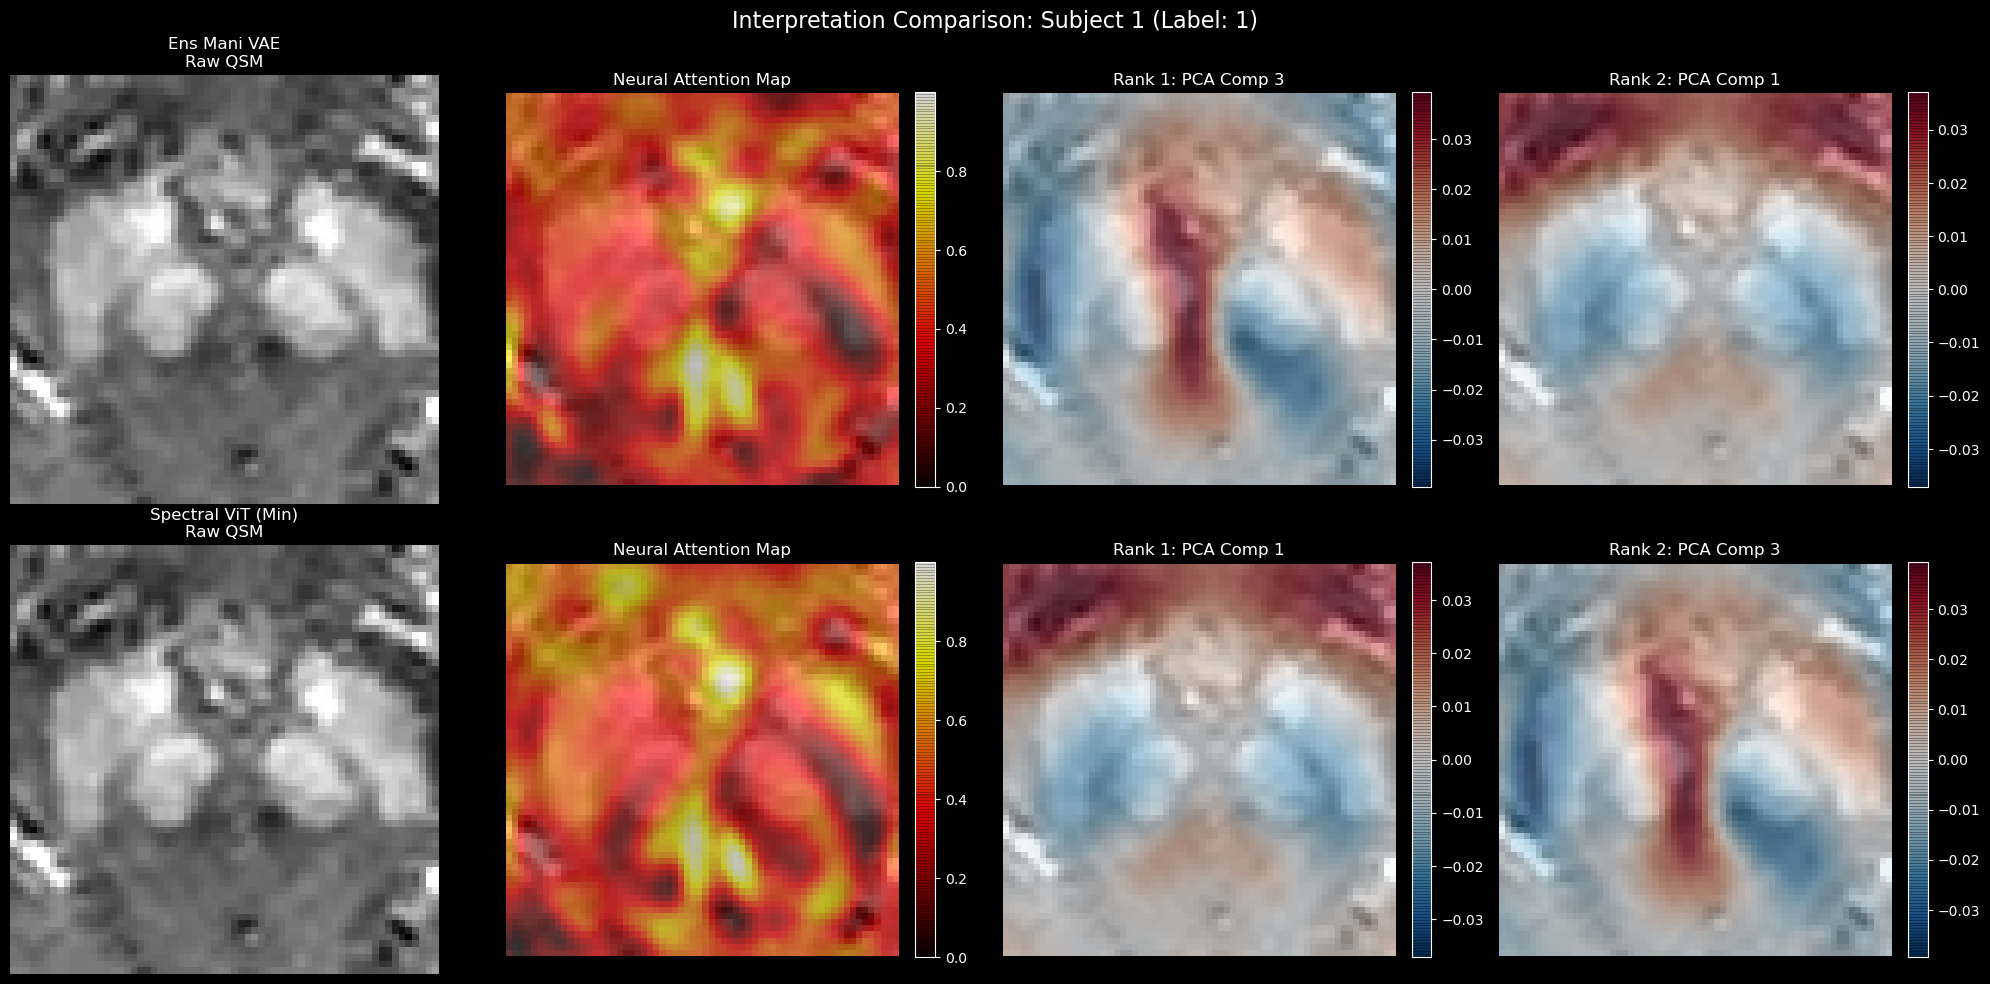

In [6]:
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.pyplot as plt
import numpy as np
import torch

def visualize_comparison_2x4(model_v, model_va, attn_va, subject_idx=0, dataset=dataset_chh):
    """
    Shows side-by-side interpretation: 
    Top Row: Ensemble Manifold VAE
    Bottom Row: Spectral ViT (Min)
    """
    plt.style.use('dark_background')
    fig, axes = plt.subplots(2, 4, figsize=(20, 10))
    
    # 1. DATA EXTRACTION
    all_sub_ids = sorted(list(set(s['sub_id'] for s in dataset.samples)))
    target_sub_id = all_sub_ids[min(subject_idx, len(all_sub_ids)-1)]
    sub_sample_indices = [i for i, s in enumerate(dataset.samples) if s['sub_id'] == target_sub_id]
    mid_sample_idx = sub_sample_indices[len(sub_sample_indices) // 2]
    
    img_tensor, clin_t, lbl, _ = dataset[mid_sample_idx]
    raw_slice = img_tensor.squeeze().numpy() 
    rotated_raw = np.rot90(raw_slice)
    
    # Prep inputs
    flat = raw_slice.flatten().reshape(1, -1)
    scaled = img_scaler.transform(flat)
    pca_feat = pca.transform(scaled)
    final_in = feat_scaler.transform(np.hstack([pca_feat, clin_t.numpy().reshape(1, -1)]))

    def get_model_insights(model, attn, input_data):
        model.eval()
        if attn: attn.eval()
        
        input_t = torch.tensor(input_data, dtype=torch.float32, device=device).requires_grad_()
        
        # Pass through attention if it exists
        feats = attn(input_t) if attn is not None else input_t
        out = model(feats, mode='fine_tune')
        out.backward()
        
        # Extract PCA gradients (first 128 elements)
        grads = input_t.grad.data.abs().cpu().numpy().squeeze()[:128]
        top_2 = np.argsort(grads)[-2:][::-1]
        
        # Saliency reconstruction
        sal_flat = np.dot(grads, pca.components_)
        sal_2d = (sal_flat.reshape(64, 64))
        sal_norm = (sal_2d - sal_2d.min()) / (sal_2d.max() - sal_2d.min() + 1e-8)
        return np.rot90(sal_norm), top_2, grads

    # 2. GET INSIGHTS FOR BOTH
    sal_v, top2_v, _ = get_model_insights(model_v, None, final_in)
    sal_va, top2_va, _ = get_model_insights(model_va, attn_va, final_in)

    def plot_row(row_idx, name, sal_img, top2_idx):
        # [0] Raw Image
        axes[row_idx, 0].imshow(rotated_raw, cmap='gray')
        axes[row_idx, 0].set_title(f"{name}\nRaw QSM")
        
        # [1] Saliency
        axes[row_idx, 1].imshow(rotated_raw, cmap='gray')
        im_s = axes[row_idx, 1].imshow(sal_img, cmap='hot', alpha=0.6)
        axes[row_idx, 1].set_title("Neural Attention Map")
        plt.colorbar(im_s, ax=axes[row_idx, 1], fraction=0.046, pad=0.04)

        # [2, 3] Top 2 Eigenimages
        for i, comp_idx in enumerate(top2_idx):
            ax = axes[row_idx, i+2]
            ax.imshow(rotated_raw, cmap='gray')
            eigen_img = np.rot90(pca.components_[comp_idx].reshape(64, 64))
            v_max = np.abs(eigen_img).max()
            im_e = ax.imshow(eigen_img, cmap='RdBu_r', vmin=-v_max, vmax=v_max, alpha=0.5)
            ax.set_title(f"Rank {i+1}: PCA Comp {comp_idx}")
            plt.colorbar(im_e, ax=ax, fraction=0.046, pad=0.04)

    # 3. RENDER
    plot_row(0, "Ens Mani VAE", sal_v, top2_v)
    plot_row(1, "Spectral ViT (Min)", sal_va, top2_va)

    for ax in axes.flatten():
        ax.axis('off')
        
    plt.suptitle(f"Interpretation Comparison: Subject {target_sub_id} (Label: {lbl})", fontsize=16)
    plt.tight_layout()
    plt.show()

# Execution
visualize_comparison_2x4(m_v, m_va, m_at, subject_idx=0)

In [3]:
import numpy as np

# 1. SEPARATE THE "TEN STATES"
# Since you appended (Balanced) then (F1) in each of the 5 folds:
ths_v_balanced = fold_ths_v[::2]
ths_v_f1       = fold_ths_v[1::2]

ths_va_balanced = fold_ths_va[::2]
ths_va_f1       = fold_ths_va[1::2]

# 2. CALCULATE THE TWO DIFFERENT MEANS
mean_th_va_balanced = np.mean(ths_va_balanced)
mean_th_va_f1       = np.mean(ths_va_f1)
current_mixed_mean  = np.mean(fold_ths_va) # What your "broken" code used

# 3. TEST THE SPECTRAL VIT WITH BOTH STRATEGIES
pva = np.mean(fold_preds_va, axis=0)

# Metrics using Balanced Thresholds
res_balanced = get_m(y_test, (pva >= mean_th_va_balanced), pva)
# Metrics using F1 Thresholds
res_f1       = get_m(y_test, (pva >= mean_th_va_f1), pva)
# Metrics using the "Mixed" average (the 10-state average)
res_mixed    = get_m(y_test, (pva >= current_mixed_mean), pva)

print("=== CALIBRATION PROOF (Spectral ViT) ===")
print(f"{'Strategy':<20} | {'Thresh':<10} | {'Sens':<10} | {'Spec':<10} | {'AUC':<10}")
print("-" * 70)
print(f"{'Balanced Accuracy':<20} | {mean_th_va_balanced:<10.4f} | {res_balanced[1]:<10.4f} | {res_balanced[2]:<10.4f} | {res_balanced[3]:<10.4f}")
print(f"{'F1 Score (Lax)':<20} | {mean_th_va_f1:<10.4f} | {res_f1[1]:<10.4f} | {res_f1[2]:<10.4f} | {res_f1[3]:<10.4f}")
print(f"{'Current Mixed Mean':<20} | {current_mixed_mean:<10.4f} | {res_mixed[1]:<10.4f} | {res_mixed[2]:<10.4f} | {res_mixed[3]:<10.4f}")

print("\n=== RAW THRESHOLD VALUES PER FOLD ===")
for i in range(5):
    print(f"Fold {i} | Balanced: {ths_va_balanced[i]:.4f} | F1: {ths_va_f1[i]:.4f}")

=== CALIBRATION PROOF (Spectral ViT) ===
Strategy             | Thresh     | Sens       | Spec       | AUC       
----------------------------------------------------------------------
Balanced Accuracy    | 0.1333     | 0.9420     | 0.6065     | 0.7657    
F1 Score (Lax)       | 0.1200     | 0.9444     | 0.5648     | 0.7657    
Current Mixed Mean   | 0.1280     | 0.9420     | 0.5833     | 0.7657    

=== RAW THRESHOLD VALUES PER FOLD ===
Fold 0 | Balanced: 0.1300 | F1: 0.1000
Fold 1 | Balanced: 0.1400 | F1: 0.1400


IndexError: list index out of range

In [ ]:
import pandas as pd

# Let's find the threshold that actually works
pva = np.mean(fold_preds_va, axis=0)
trials = []

for t in np.linspace(0, 1.0, 101):
    res = get_m(y_test, (pva >= t), pva)
    trials.append({'threshold': t, 'acc': res[0], 'sens': res[1], 'spec': res[2]})

df = pd.DataFrame(trials)
# Find the highest specificity where sensitivity is still > 0.80
best_spot = df[df['sens'] > 0.80].sort_values(by='spec', ascending=False).iloc[0]

print("=== OPTIMAL THRESHOLD SEARCH ===")
print(best_spot)